In [1]:
# ============================================================
# Cell 1 : Imports
# ============================================================

import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    convnext_tiny,
    ConvNeXt_Tiny_Weights
)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# Cell 2 : Configuration
# ============================================================

SEED = 42

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_WORKERS = 2

NUM_CLASSES = 14

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATASET_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

MODEL_PATH = "/kaggle/input/models/swastikprakash/con/pytorch/default/1/best_convnext_baseline.pth"

print("Device :", DEVICE)

Device : cuda


In [3]:
# ============================================================
# Cell 3 : Disease Labels
# ============================================================

DISEASES = [

    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax"

]

In [4]:
# ============================================================
# Cell 4 : Metadata
# ============================================================

metadata = pd.read_csv(

    os.path.join(
        DATASET_PATH,
        "Data_Entry_2017.csv"
    )

)

metadata = metadata.drop(
    columns=["Unnamed: 11"],
    errors="ignore"
)

print(metadata.shape)

(112120, 11)


In [5]:
# ============================================================
# Cell 5 : Image Paths
# ============================================================

from glob import glob

IMAGE_PATH_DICT = {}

image_files = glob(
    os.path.join(
        DATASET_PATH,
        "images_*",
        "images",
        "*.png"
    )
)

for img in image_files:

    IMAGE_PATH_DICT[
        os.path.basename(img)
    ] = img

metadata["Image Path"] = metadata[
    "Image Index"
].map(
    IMAGE_PATH_DICT
)

metadata = metadata.dropna().reset_index(drop=True)

print(metadata.shape)

(112120, 12)


In [6]:
# ============================================================
# Cell 6 : Labels
# ============================================================

for disease in DISEASES:

    metadata[disease] = metadata[
        "Finding Labels"
    ].apply(

        lambda x: int(
            disease in x.split("|")
        )

    )

metadata.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,0,1,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,1,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,0
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,0,0,1,0,0,0,0,0,0


In [7]:
# ============================================================
# Cell 7 : Patient Split
# ============================================================

gss = GroupShuffleSplit(

    n_splits=1,

    train_size=0.70,

    random_state=SEED

)

train_idx, temp_idx = next(

    gss.split(

        metadata,

        groups=metadata["Patient ID"]

    )

)

train_df = metadata.iloc[
    train_idx
].reset_index(drop=True)

print(len(train_df))

78566


In [8]:
# ============================================================
# Cell 8 : CLAHE
# ============================================================

def apply_clahe(image):

    clahe = cv2.createCLAHE(

        clipLimit=2,

        tileGridSize=(8,8)

    )

    return clahe.apply(image)

In [9]:
# ============================================================
# Cell 9 : Transform
# ============================================================

transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize(
        (224,224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

In [10]:
# ============================================================
# Cell 10 : Build ConvNeXt-Tiny
# ============================================================

weights = ConvNeXt_Tiny_Weights.DEFAULT

model = convnext_tiny(weights=weights)

in_features = model.classifier[2].in_features

model.classifier[2] = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 248MB/s] 


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=14, bias=True)
)


In [11]:
import os

print("="*80)

for root, dirs, files in os.walk("/kaggle/input/models"):

    print(root)

    for f in files:
        print("   ", f)

print("="*80)

/kaggle/input/models
/kaggle/input/models/swastikprakash
/kaggle/input/models/swastikprakash/conv
/kaggle/input/models/swastikprakash/conv/pytorch
/kaggle/input/models/swastikprakash/conv/pytorch/default
/kaggle/input/models/swastikprakash/conv/pytorch/default/1
    best_convnext_baseline.pth


In [12]:
# ============================================================
# Cell 11 : Load Baseline Checkpoint
# ============================================================

MODEL_PATH = "/kaggle/input/models/swastikprakash/conv/pytorch/default/1/best_convnext_baseline.pth"

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

print("="*60)
print("Checkpoint Loaded Successfully")
print("="*60)

print("Checkpoint Keys:")
print(checkpoint.keys())

Checkpoint Loaded Successfully
Checkpoint Keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_auc', 'history'])


In [13]:
# ============================================================
# Cell 12 : Restore Baseline Weights
# ============================================================

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

history = checkpoint["history"]

print("="*60)
print("✅ Baseline ConvNeXt Loaded")
print(f"Best AUROC : {checkpoint['best_auc']:.4f}")
print(f"Epoch      : {checkpoint['epoch']}")
print("="*60)

✅ Baseline ConvNeXt Loaded
Best AUROC : 0.8371
Epoch      : 6


In [14]:
# ============================================================
# Cell 13 : Remove Classification Head
# ============================================================

class ConvNeXtFeatureExtractor(nn.Module):

    def __init__(self, backbone):

        super().__init__()

        self.features = backbone.features
        self.avgpool = backbone.avgpool

    def forward(self, x):

        x = self.features(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        return x


encoder = ConvNeXtFeatureExtractor(model)

encoder = encoder.to(DEVICE)

encoder.eval()

print("="*60)
print("Feature Extractor Created")
print("="*60)

Feature Extractor Created


In [15]:
# ============================================================
# Cell 14 : Verify Embedding Size
# ============================================================

dummy = torch.randn(
    4,
    3,
    224,
    224
).to(DEVICE)

with torch.no_grad():

    embedding = encoder(dummy)

print("="*60)
print("Embedding Shape :", embedding.shape)
print("="*60)

Embedding Shape : torch.Size([4, 768])


In [16]:
# ============================================================
# Cell 15 : Training Dataset
# ============================================================

class NIHEmbeddingDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = cv2.imread(
            row["Image Path"],
            cv2.IMREAD_GRAYSCALE
        )

        image = apply_clahe(image)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_GRAY2RGB
        )

        image = transform(image)

        label = row[DISEASES].values.astype(np.float32)

        return image, torch.tensor(label)

In [17]:
# ============================================================
# Cell 16 : DataLoader
# ============================================================

train_dataset = NIHEmbeddingDataset(train_df)

train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)

print("Training Images :", len(train_dataset))
print("Training Batches :", len(train_loader))

Training Images : 78566
Training Batches : 1228


In [18]:
# ============================================================
# Cell 17 : Extract Sample Embeddings
# ============================================================

images, labels = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():

    embeddings = encoder(images)

print("="*60)

print("Embedding Tensor Shape :", embeddings.shape)

print("Label Shape :", labels.shape)

print("="*60)

Embedding Tensor Shape : torch.Size([64, 768])
Label Shape : torch.Size([64, 14])


In [19]:
# ============================================================
# Cell 18 : Save Embeddings
# ============================================================

sample_embeddings = embeddings.cpu().numpy()

np.save(

    "/kaggle/working/sample_embeddings.npy",

    sample_embeddings

)

print("="*60)
print("Embeddings Saved Successfully")
print(sample_embeddings.shape)
print("="*60)

Embeddings Saved Successfully
(64, 768)


In [20]:
# ============================================================
# Cell 19 : Embedding Statistics
# ============================================================

emb = sample_embeddings

print("="*60)

print("Embedding Dimension :", emb.shape)

print("Mean :", np.mean(emb))

print("Std :", np.std(emb))

print("Min :", np.min(emb))

print("Max :", np.max(emb))

print("="*60)

Embedding Dimension : (64, 768)
Mean : 0.0077324356
Std : 0.19474754
Min : -2.0645323
Max : 2.807907


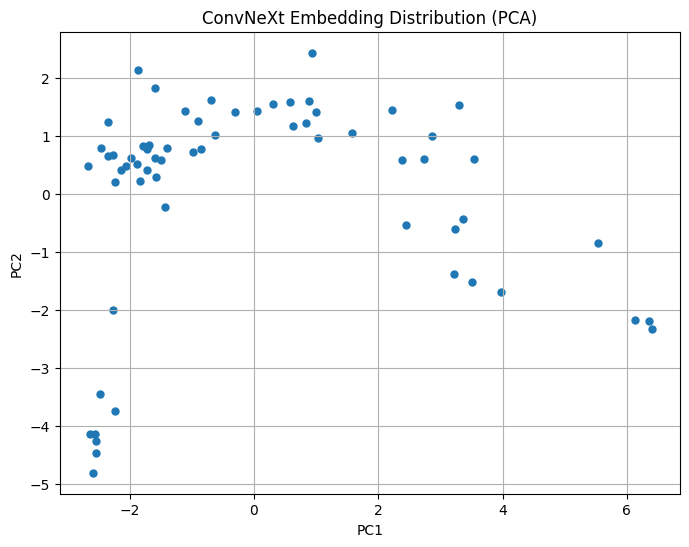

In [21]:
# ============================================================
# Cell 20 : PCA Visualization
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

embedding_2d = pca.fit_transform(sample_embeddings)

plt.figure(figsize=(8,6))

plt.scatter(

    embedding_2d[:,0],

    embedding_2d[:,1],

    s=25

)

plt.title("ConvNeXt Embedding Distribution (PCA)")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.grid(True)

plt.show()

In [22]:
# ============================================================
# Cell 21 : Projection Head
# ============================================================

class ProjectionHead(nn.Module):

    def __init__(
        self,
        input_dim=768,
        hidden_dim=512,
        output_dim=128
    ):

        super().__init__()

        self.projection = nn.Sequential(

            nn.Linear(input_dim, hidden_dim),

            nn.ReLU(inplace=True),

            nn.Linear(hidden_dim, output_dim)

        )

    def forward(self, x):

        x = self.projection(x)

        x = F.normalize(x, dim=1)

        return x


projection_head = ProjectionHead().to(DEVICE)

print(projection_head)

ProjectionHead(
  (projection): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=128, bias=True)
  )
)


In [23]:
# ============================================================
# Cell 22 : SupCon Model
# ============================================================

class SupConModel(nn.Module):

    def __init__(self, encoder, projection):

        super().__init__()

        self.encoder = encoder

        self.projection = projection

    def forward(self, x):

        features = self.encoder(x)

        projections = self.projection(features)

        return features, projections


supcon_model = SupConModel(
    encoder,
    projection_head
).to(DEVICE)

print(supcon_model)

SupConModel(
  (encoder): ConvNeXtFeatureExtractor(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2):

In [24]:
# ============================================================
# Cell 23 : Verify Model
# ============================================================

dummy = torch.randn(
    8,
    3,
    224,
    224
).to(DEVICE)

with torch.no_grad():

    features, projections = supcon_model(dummy)

print("="*60)

print("Encoder Features :", features.shape)

print("Projection Output :", projections.shape)

print("="*60)

Encoder Features : torch.Size([8, 768])
Projection Output : torch.Size([8, 128])


In [25]:
# ============================================================
# Cell 24 : Supervised Contrastive Loss
# ============================================================

class SupConLoss(nn.Module):

    def __init__(
        self,
        temperature=0.07
    ):

        super().__init__()

        self.temperature = temperature

    def forward(
        self,
        features,
        labels
    ):

        labels = labels.float()

        similarity = torch.matmul(
            features,
            features.T
        ) / self.temperature

        mask = torch.matmul(
            labels,
            labels.T
        ) > 0

        logits_mask = torch.ones_like(mask)

        logits_mask.fill_diagonal_(0)

        mask = mask * logits_mask

        exp_logits = torch.exp(similarity) * logits_mask

        log_prob = similarity - torch.log(
            exp_logits.sum(1, keepdim=True) + 1e-12
        )

        mean_log_prob = (
            mask * log_prob
        ).sum(1) / (mask.sum(1) + 1e-12)

        loss = -mean_log_prob.mean()

        return loss


criterion = SupConLoss()

print("SupCon Loss Ready")

SupCon Loss Ready


In [26]:
# ============================================================
# Cell 25 : Test SupCon Loss
# ============================================================

dummy_features = F.normalize(
    torch.randn(16,128),
    dim=1
)

dummy_labels = torch.randint(
    0,
    2,
    (16,14)
).float()

loss = criterion(
    dummy_features,
    dummy_labels
)

print("="*60)

print("Dummy SupCon Loss :", loss.item())

print("="*60)

Dummy SupCon Loss : 3.490271806716919


In [27]:
# ============================================================
# Cell 26 : Optimizer
# ============================================================

LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(

    supcon_model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY

)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0.0001
)


In [28]:
# ============================================================
# Cell 27 : Scheduler
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20,

    eta_min=1e-7

)

print("Cosine Annealing Scheduler Ready")

Cosine Annealing Scheduler Ready


In [29]:
# ============================================================
# Cell 28 : AMP
# ============================================================

scaler = torch.cuda.amp.GradScaler()

print("Mixed Precision Enabled")

Mixed Precision Enabled


In [30]:
# ============================================================
# Cell 29 : Train One Epoch
# ============================================================

def train_one_epoch_supcon(model,
                           loader,
                           optimizer,
                           criterion,
                           scaler):

    model.train()

    running_loss = 0

    for images, labels in tqdm(loader):

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            _, projections = model(images)

            loss = criterion(
                projections,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

    return running_loss / len(loader)

In [31]:
# ============================================================
# Cell 30 : Training Config
# ============================================================

EPOCHS = 20

history_supcon = {
    "loss": []
}

BEST_LOSS = float("inf")

SAVE_PATH = "/kaggle/working/best_supcon_encoder.pth"

print("Ready for Training")

Ready for Training


In [32]:
# ============================================================
# Cell 31 : SupCon Training
# ============================================================

for epoch in range(EPOCHS):

    print("="*70)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("="*70)

    loss = train_one_epoch_supcon(

        supcon_model,

        train_loader,

        optimizer,

        criterion,

        scaler

    )

    scheduler.step()

    history_supcon["loss"].append(loss)

    print(f"Training Loss : {loss:.4f}")

    if loss < BEST_LOSS:

        BEST_LOSS = loss

        torch.save({

            "encoder_state_dict": encoder.state_dict(),

            "projection_head_state_dict": projection_head.state_dict(),

            "optimizer_state_dict": optimizer.state_dict(),

            "loss": BEST_LOSS,

            "epoch": epoch

        }, SAVE_PATH)

        print("✅ Best SupCon Model Saved")

print("="*70)
print("SupCon Training Finished")
print(f"Best Loss : {BEST_LOSS:.4f}")
print("="*70)

Epoch 1/20


  0%|          | 0/1228 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


Training Loss : 1.7553
✅ Best SupCon Model Saved
Epoch 2/20


  0%|          | 0/1228 [00:00<?, ?it/s]

...

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


Training Loss : 1.4128
Epoch 20/20


  0%|          | 0/1228 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


Training Loss : 1.4119
✅ Best SupCon Model Saved
SupCon Training Finished
Best Loss : 1.4119


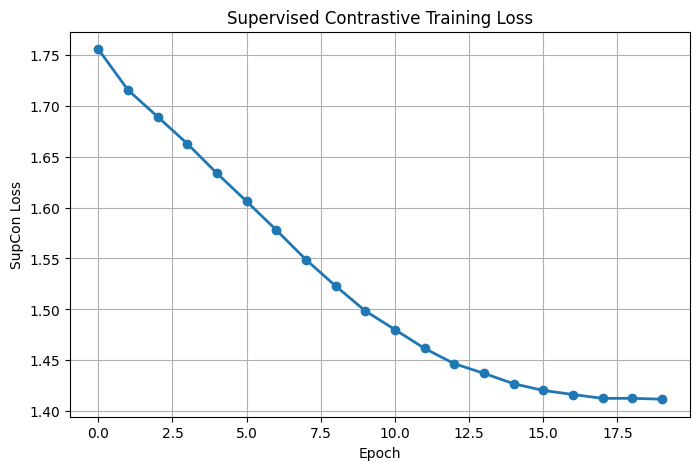

In [33]:
# ============================================================
# Cell 32 : Loss Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    history_supcon["loss"],

    marker="o",

    linewidth=2

)

plt.xlabel("Epoch")

plt.ylabel("SupCon Loss")

plt.title("Supervised Contrastive Training Loss")

plt.grid(True)

plt.show()